## Part 1. Explainability 

In [5]:
# ── Cellule 1 — Imports + Rechargement du modèle Failure Prediction ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

In [7]:
# ── Cellule 1 — Imports + Rechargement complet ──
import os
os.environ.setdefault("NUMBA_DISABLE_COVERAGE", "1")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# ── Chargement et preprocessing complet ──
csv_path = Path("student_dataset") / "student_failure" / "train.csv"
df = pd.read_csv(csv_path)

df = df.drop(columns=['taille_etudiant', 'id'], errors='ignore')
df = pd.get_dummies(df, drop_first=True)

X = df.drop("score_examen", axis=1)
y = df["score_examen"]

numeric_cols = X.select_dtypes(include="number").columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Split identique
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled_df, y, test_size=0.20, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

# Réentraîner XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42,
                   verbosity=0, n_jobs=1, base_score=0.5)
xgb.fit(X_train, y_train)
print("XGBoost réentraîné !")
print(f"Colonnes : {list(X.columns)}")

XGBoost réentraîné !
Colonnes : ['age', 'heures_etude', 'assiduité_classe', 'heures_sommeil', 'heures_fête', 'genre_male', 'diplôme_Business Administration', 'diplôme_Business Management', 'diplôme_Computer Science', 'diplôme_Engineering', 'diplôme_Law', 'diplôme_Marketing', 'accès_internet_yes', 'qualité_sommeil_good', 'qualité_sommeil_poor', 'méthode_etude_group study', 'méthode_etude_mixed', 'méthode_etude_online videos', 'méthode_etude_self-study', 'évaluation_établissement_low', 'évaluation_établissement_medium', 'difficulté_examen_hard', 'difficulté_examen_moderate']


/var/folders/mw/9gyzx1kx6cn39r2jqgbbq7l80000gn/T/ipykernel_90316/1234639539.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


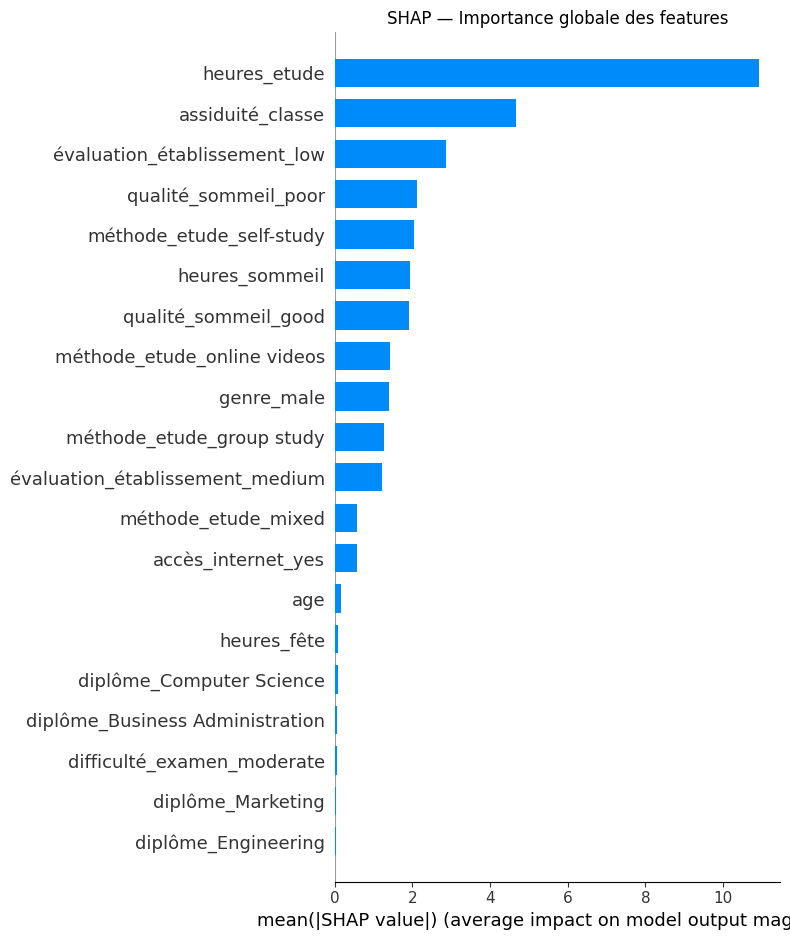

Graphe global sauvegardé !


In [8]:
# ── Cellule 2 — SHAP Global : importance globale des features ──

# X_test est un numpy array — on le reconvertit en DataFrame
X_test_df = pd.DataFrame(X_test, columns=X.columns)
X_sample = X_test_df.iloc[:300].copy()  # 300 pour être safe sur la RAM

# Fix compatibilité XGBoost 3.x / SHAP — on utilise l'explainer model-agnostique
explainer = shap.Explainer(xgb.predict, X_sample)
shap_values = explainer(X_sample, max_evals=2 * X_sample.shape[1] + 1)

# Summary plot — vue globale
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("SHAP — Importance globale des features")
plt.tight_layout()
plt.savefig("shap_global.png", dpi=150, bbox_inches='tight')
plt.show()
print("Graphe global sauvegardé !")

Étudiant sélectionné — index : 4
Score prédit : 47.59
Score réel   : 50.40


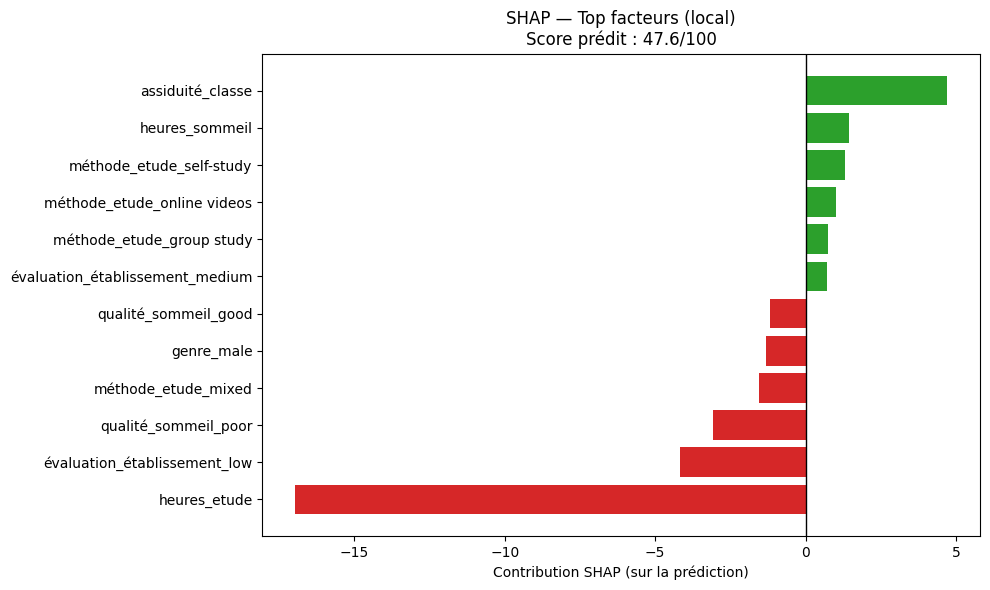


EXPLICATION POUR L'ÉTUDIANT
Score prédit         : 47.6/100
Score moyen dataset  : 63.4/100

Top 5 facteurs qui influencent ce score :
  1. heures_etude                        : -16.972 (↓ pénalise)
  2. assiduité_classe                    : +4.709 (↑ aide)
  3. évaluation_établissement_low        : -4.163 (↓ pénalise)
  4. qualité_sommeil_poor                : -3.088 (↓ pénalise)
  5. méthode_etude_mixed                 : -1.560 (↓ pénalise)


In [9]:
# ── Cellule 3 — SHAP Local : explication pour UN étudiant à risque ──

X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Trouver un étudiant avec score prédit < 50
preds = xgb.predict(X_test)
at_risk_indices = np.where(preds < 50)[0]
student_idx = int(at_risk_indices[0])

print(f"Étudiant sélectionné — index : {student_idx}")
print(f"Score prédit : {preds[student_idx]:.2f}")
print(f"Score réel   : {y_test.iloc[student_idx]:.2f}")

# Student + background (important pour des SHAP values non-nulles)
X_student = X_test_df.iloc[student_idx:student_idx+1].copy()
bg_n = min(100, len(X_test_df))
X_background = X_test_df.sample(bg_n, random_state=42)

# Calculer les valeurs SHAP pour cet étudiant
explainer_local = shap.Explainer(xgb.predict, X_background)
shap_values_single = explainer_local(
    X_student,
    max_evals=2 * X_student.shape[1] + 1
)

# --- Plot robuste (évite shap.plots.waterfall qui peut exploser la taille de l'image) ---
vals = shap_values_single.values[0]
k = 12
topk = np.argsort(np.abs(vals))[::-1][:k]

plot_df = pd.DataFrame({
    'feature': X.columns[topk],
    'shap': vals[topk],
    'value': X_student.iloc[0, topk].to_numpy(),
}).sort_values('shap', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['tab:red' if v < 0 else 'tab:green' for v in plot_df['shap']]
plt.barh(plot_df['feature'], plot_df['shap'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title(f"SHAP — Top facteurs (local)\nScore prédit : {preds[student_idx]:.1f}/100")
plt.xlabel('Contribution SHAP (sur la prédiction)')
plt.tight_layout()
plt.savefig("shap_local.png", dpi=150)
plt.show()
plt.close()

# Résumé textuel
print("\n" + "="*60)
print("EXPLICATION POUR L'ÉTUDIANT")
print("="*60)
print(f"Score prédit         : {preds[student_idx]:.1f}/100")
print(f"Score moyen dataset  : {y_train.mean():.1f}/100")
print(f"\nTop 5 facteurs qui influencent ce score :")
top5 = np.argsort(np.abs(vals))[::-1][:5]
for i, idx in enumerate(top5):
    val = vals[idx]
    direction = "↓ pénalise" if val < 0 else "↑ aide"
    print(f"  {i+1}. {X.columns[idx]:35s} : {val:+.3f} ({direction})")

In [10]:
# Libérer la mémoire avant de charger le CNN
import gc
import torch

# Supprimer les variables XGBoost et SHAP de la mémoire
for var in ['xgb', 'xgb_ns', 'xgb_rw', 'shap_values', 
            'explainer', 'X_full_scaled', 'X_temp2']:
    if var in dir():
        del var

gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("Mémoire libérée !")

Mémoire libérée !


## Cellule 4 : Réentraînement CNN

In [ ]:
# ── Cellule 4 — CNN (stable) : chargement ou entraînement léger pour Grad-CAM ──
import os
import struct
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Réduire les risques de crash natif (macOS)
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
torch.manual_seed(42)
np.random.seed(42)

# Par défaut on force CPU (le plus stable pour ce TP)
device = torch.device("cpu")
print("Device:", device)

# Copie de la classe CNN (OCR)
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.classifier(x)
        return x

# Dataset OCR (mémoire-safe: memmap + normalisation à la volée)
class MyDataset(Dataset):
    def __init__(self, images_path, labels_path, mapping_path):
        with open(images_path, "rb") as f:
            magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        with open(labels_path, "rb") as f:
            magic2, num2 = struct.unpack(">II", f.read(8))
        assert num == num2, "Images/labels: tailles différentes"

        self.num = num
        self.rows = rows
        self.cols = cols

        # Memmap: ne charge pas toutes les images en RAM
        self.images_mm = np.memmap(
            images_path, dtype=np.uint8, mode="r", offset=16, shape=(num, rows, cols)
        )
        self.labels_mm = np.memmap(
            labels_path, dtype=np.uint8, mode="r", offset=8, shape=(num,)
        )

        self.mapping = {}
        with open(mapping_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith("#"):
                    continue
                parts = line.split()
                if len(parts) != 2:
                    continue
                idx_str, ascii_str = parts
                self.mapping[int(idx_str)] = chr(int(ascii_str))
        self.num_classes = len(self.mapping)

    def __len__(self):
        return self.num

    def __getitem__(self, idx):
        # Même orientation que le notebook OCR: transpose (28,28) -> (28,28) swap axes
        img = self.images_mm[idx].T.copy()  # copie petite (28x28) pour être contigu
        img = torch.from_numpy(img).to(torch.float32) / 255.0
        lbl = int(self.labels_mm[idx])
        return img.unsqueeze(0), torch.tensor(lbl, dtype=torch.long)

print("Chargement du dataset OCR...")
images_file  = "student_dataset/image_data/train-images-idx3-ubyte"
labels_file  = "student_dataset/image_data/train-labels-idx1-ubyte"
mapping_path = "student_dataset/image_data/mapping.txt"

dataset_full = MyDataset(images_file, labels_file, mapping_path)
print(f"Dataset complet : {len(dataset_full)} images | classes={dataset_full.num_classes}")

# Sous-échantillonnage (pour stabilité)
max_subset = 5000
subset_size = min(max_subset, len(dataset_full))
subset_indices = torch.randperm(len(dataset_full), generator=torch.Generator().manual_seed(42))[:subset_size].tolist()

# Subset sans duplication des données
class SubsetDataset(Dataset):
    def __init__(self, base, indices):
        self.base = base
        self.indices = indices
        self.mapping = base.mapping
        self.num_classes = base.num_classes
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        return self.base[self.indices[i]]

dataset = SubsetDataset(dataset_full, subset_indices)
print(f"Dataset réduit : {len(dataset)} images")

# Split
total = len(dataset)
n_train = int(total * 0.70)
n_val   = int(total * 0.15)
n_test  = total - n_train - n_val
train_set, val_set, test_set = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42),
 )

# Dataloaders (num_workers=0 sur macOS pour éviter des soucis)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False, num_workers=0)

# Modèle
model = CNN(num_classes=dataset.num_classes).to(device)
weights_path = "ocr_model.pth"

# Si on a déjà un modèle sur disque, on le charge pour éviter de réentraîner
if os.path.exists(weights_path):
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print(f"Poids chargés depuis {weights_path} (pas de réentraînement).")
else:
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    epochs = 2
    print(f"\nEntraînement léger du CNN ({epochs} epochs)...")
    for epoch in range(epochs):
        model.train()
        correct, total_count = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            correct += (outputs.argmax(1) == labels).sum().item()
            total_count += labels.size(0)
        print(f"Epoch {epoch+1}/{epochs} — Accuracy train : {correct/total_count:.4f}")
    torch.save(model.state_dict(), weights_path)
    print(f"\nModèle sauvegardé — {weights_path} !")

Device: cpu
Chargement du dataset OCR...
Dataset complet : 697932 images | classes=62
Dataset réduit : 5000 images
Poids chargés depuis ocr_model.pth (pas de réentraînement).


## Cellule 5 : Grad-CAM (zones importantes de l'image)

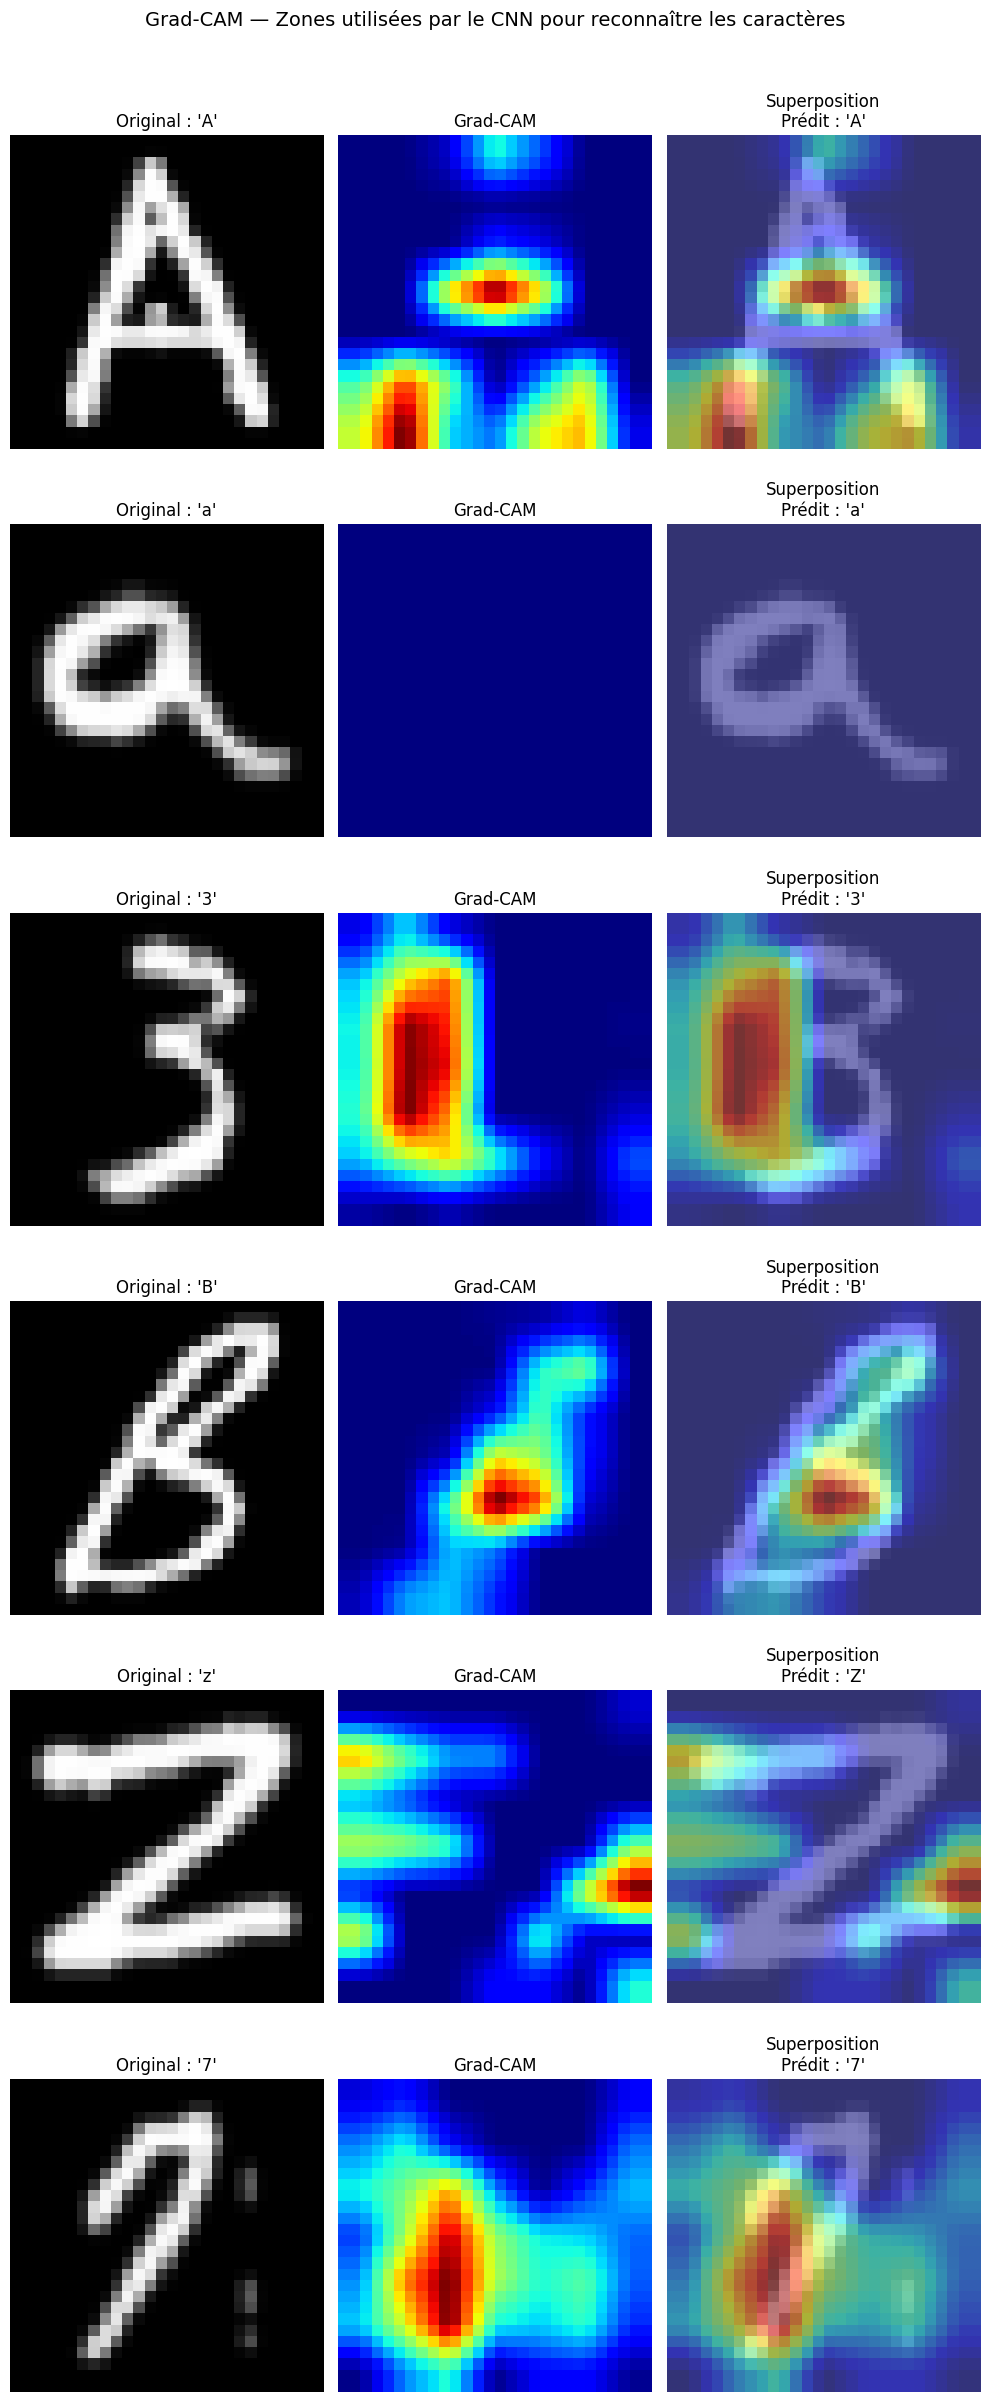

Grad-CAM sauvegardé !


In [12]:
# ── Cellule 5 — Grad-CAM : zones importantes de l'image pour le CNN ──

model.eval()

# ── Fonction Grad-CAM ──
def grad_cam(model, image_tensor, target_class):
    gradients = []
    activations = []

    # Hook pour capturer les activations et gradients de conv3
    def forward_hook(module, input, output):
        activations.append(output.detach())

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    # Enregistrer les hooks sur conv3
    fwd_handle = model.conv3[0].register_forward_hook(forward_hook)
    bwd_handle = model.conv3[0].register_full_backward_hook(backward_hook)

    # Forward pass
    image_tensor = image_tensor.unsqueeze(0).to(device)
    output = model(image_tensor)

    # Backward pass sur la classe cible
    model.zero_grad()
    output[0, target_class].backward()

    # Retirer les hooks
    fwd_handle.remove()
    bwd_handle.remove()

    # Calculer la carte d'activation
    grad = gradients[0].squeeze()       # (128, 7, 7)
    act  = activations[0].squeeze()     # (128, 7, 7)
    weights = grad.mean(dim=(1, 2))     # moyenne spatiale des gradients

    # Combinaison pondérée des canaux
    cam = (weights[:, None, None] * act).sum(dim=0)
    cam = F.relu(cam)

    # Normalisation entre 0 et 1
    if cam.max() > 0:
        cam = cam / cam.max()

    # Upscale vers 28x28
    cam = F.interpolate(
        cam.unsqueeze(0).unsqueeze(0),
        size=(28, 28),
        mode='bilinear',
        align_corners=False
    ).squeeze().cpu().numpy()

    return cam

# ── Visualisation sur plusieurs caractères ──
# Prendre des exemples variés du test set
chars_to_show = ['A', 'a', '3', 'B', 'z', '7']
mapping_inv = {v: k for k, v in dataset.mapping.items()}

fig, axes = plt.subplots(len(chars_to_show), 3, figsize=(10, 4 * len(chars_to_show)))

for row, char in enumerate(chars_to_show):
    if char not in mapping_inv:
        continue
    target_idx = mapping_inv[char]

    # Trouver une image de ce caractère dans le test set
    found = False
    for i in range(len(test_set)):
        img, lbl = test_set[i]
        if lbl.item() == target_idx:
            image = img
            found = True
            break

    if not found:
        continue

    # Calculer Grad-CAM
    cam = grad_cam(model, image, target_idx)
    img_np = image.squeeze().cpu().numpy()

    # Prédiction du modèle
    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(device)).argmax(1).item()
    pred_char = dataset.mapping[pred]

    # Colonne 1 — Image originale
    axes[row, 0].imshow(img_np, cmap='gray')
    axes[row, 0].set_title(f"Original : '{char}'", fontsize=12)
    axes[row, 0].axis('off')

    # Colonne 2 — Carte Grad-CAM seule
    axes[row, 1].imshow(cam, cmap='jet')
    axes[row, 1].set_title(f"Grad-CAM", fontsize=12)
    axes[row, 1].axis('off')

    # Colonne 3 — Superposition
    axes[row, 2].imshow(img_np, cmap='gray', alpha=0.6)
    axes[row, 2].imshow(cam, cmap='jet', alpha=0.5)
    axes[row, 2].set_title(f"Superposition\nPrédit : '{pred_char}'", fontsize=12)
    axes[row, 2].axis('off')

plt.suptitle("Grad-CAM — Zones utilisées par le CNN pour reconnaître les caractères",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("grad_cam.png", dpi=150, bbox_inches='tight')
plt.show()
print("Grad-CAM sauvegardé !")

## Part 2. Bias 

### Cellule de vérification 

In [13]:
# Vérification — est-ce qu'on a accès aux labels originaux ?
import pandas as pd
from pathlib import Path

csv_path = Path("student_dataset") / "student_failure" / "train.csv"
df_original = pd.read_csv(csv_path)

print("Colonnes disponibles :", df_original.columns.tolist())
print("\nValeurs uniques genre :", df_original['genre'].unique())
print("Valeurs uniques diplôme :", df_original['diplôme'].unique())
print("\nTaille du dataset :", len(df_original))

Colonnes disponibles : ['id', 'age', 'genre', 'diplôme', 'heures_etude', 'assiduité_classe', 'accès_internet', 'heures_sommeil', 'qualité_sommeil', 'méthode_etude', 'évaluation_établissement', 'difficulté_examen', 'score_examen', 'heures_fête', 'taille_etudiant']

Valeurs uniques genre : ['male' 'female']
Valeurs uniques diplôme : ['Computer Science' 'Law' 'Business Management' 'Marketing'
 'Bachelor of Arts' 'Business Administration' 'Engineering']

Taille du dataset : 630000


## Cellule 6 : Analyse du biais par genre et diplôme

Réentraînement de XGBoost...
XGBoost prêt !
ANALYSE DU BIAIS — RMSE PAR GROUPE

1. BIAIS PAR GENRE
----------------------------------------
RMSE global : 9.3080
RMSE male     ( 73087 étudiants) : 9.3374
RMSE female   ( 52913 étudiants) : 9.2671
Écart male/female : 0.0703

2. BIAIS PAR DIPLÔME
----------------------------------------
RMSE Bachelor of Arts               (12307) : 9.5001
RMSE Business Administration        (15111) : 9.2642
RMSE Business Management            (17751) : 9.4260
RMSE Computer Science               (22304) : 9.3554
RMSE Engineering                    (26237) : 9.2998
RMSE Law                            (10080) : 9.2431
RMSE Marketing                      (22210) : 9.1244


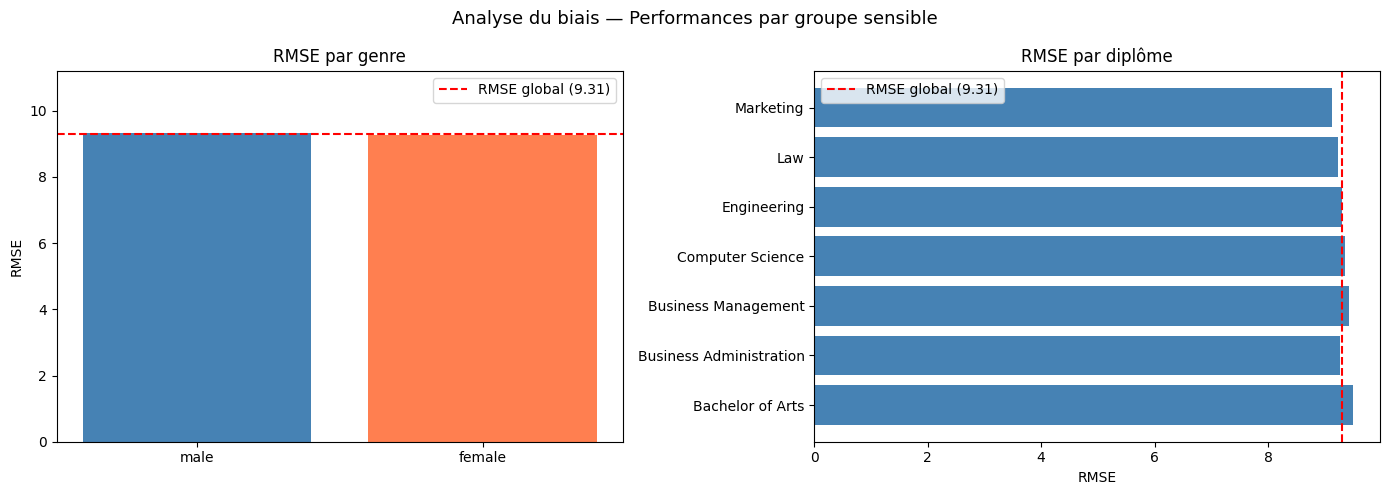


Graphe sauvegardé !


In [14]:
# ── Cellule 6 — Analyse du biais par variable sensible ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# Recharger le dataset original avec les labels texte
csv_path = Path("student_dataset") / "student_failure" / "train.csv"
df_original = pd.read_csv(csv_path)

df_work = df_original.drop(columns=['taille_etudiant', 'id'], errors='ignore')

# Garder les colonnes sensibles AVANT encoding
sensitive_cols = df_work[['genre', 'diplôme', 'age']].copy()

df_encoded = pd.get_dummies(df_work, drop_first=True)
X_full = df_encoded.drop("score_examen", axis=1)
y_full = df_encoded["score_examen"]

numeric_cols = X_full.select_dtypes(include="number").columns
X_full[numeric_cols] = X_full[numeric_cols].fillna(X_full[numeric_cols].median())

scaler2 = StandardScaler()
X_full_scaled = scaler2.fit_transform(X_full)

# Split identique
X_temp2, X_test2, y_temp2, y_test2, idx_temp, idx_test = train_test_split(
    X_full_scaled, y_full, sensitive_cols.index,
    test_size=0.20, random_state=42
)
X_train2, X_val2, y_train2, y_val2, _, _ = train_test_split(
    X_temp2, y_temp2, idx_temp,
    test_size=0.25, random_state=42
)

# Réentraîner XGBoost
print("Réentraînement de XGBoost...")
xgb = XGBRegressor(n_estimators=100, random_state=42,
                   verbosity=0, n_jobs=1, base_score=0.5)
xgb.fit(X_train2, y_train2)
print("XGBoost prêt !")

# Récupérer les labels sensibles du test set
sensitive_test = sensitive_cols.loc[idx_test].reset_index(drop=True)
y_test2 = y_test2.reset_index(drop=True)

# Prédictions
preds_test = xgb.predict(X_test2)

print("="*55)
print("ANALYSE DU BIAIS — RMSE PAR GROUPE")
print("="*55)

# ── Biais par genre ──
print("\n1. BIAIS PAR GENRE")
print("-"*40)
rmse_global = mean_squared_error(y_test2, preds_test) ** 0.5
print(f"RMSE global : {rmse_global:.4f}")

genre_rmse = {}
for genre in ['male', 'female']:
    mask = sensitive_test['genre'] == genre
    rmse = mean_squared_error(
        y_test2[mask], preds_test[mask]
    ) ** 0.5
    genre_rmse[genre] = rmse
    n = mask.sum()
    print(f"RMSE {genre:8s} ({n:6d} étudiants) : {rmse:.4f}")

print(f"Écart male/female : {abs(genre_rmse['male'] - genre_rmse['female']):.4f}")

# ── Biais par diplôme ──
print("\n2. BIAIS PAR DIPLÔME")
print("-"*40)
diplomes = df_original['diplôme'].unique()
diplome_rmse = {}
for diplome in sorted(diplomes):
    mask = sensitive_test['diplôme'] == diplome
    if mask.sum() < 10:
        continue
    rmse = mean_squared_error(
        y_test2[mask], preds_test[mask]
    ) ** 0.5
    diplome_rmse[diplome] = rmse
    n = mask.sum()
    print(f"RMSE {diplome:30s} ({n:5d}) : {rmse:.4f}")

# ── Visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphe 1 — Biais par genre
axes[0].bar(
    list(genre_rmse.keys()),
    list(genre_rmse.values()),
    color=['steelblue', 'coral']
)
axes[0].axhline(y=rmse_global, color='red', linestyle='--',
                linewidth=1.5, label=f'RMSE global ({rmse_global:.2f})')
axes[0].set_title("RMSE par genre")
axes[0].set_ylabel("RMSE")
axes[0].legend()
axes[0].set_ylim(0, max(genre_rmse.values()) * 1.2)

# Graphe 2 — Biais par diplôme
axes[1].barh(
    list(diplome_rmse.keys()),
    list(diplome_rmse.values()),
    color='steelblue'
)
axes[1].axvline(x=rmse_global, color='red', linestyle='--',
                linewidth=1.5, label=f'RMSE global ({rmse_global:.2f})')
axes[1].set_title("RMSE par diplôme")
axes[1].set_xlabel("RMSE")
axes[1].legend()

plt.suptitle("Analyse du biais — Performances par groupe sensible", fontsize=13)
plt.tight_layout()
plt.savefig("bias_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGraphe sauvegardé !")

## Cellule 7. Mitigation du biais


MITIGATION DU BIAIS

1. SUPPRESSION DES VARIABLES SENSIBLES
----------------------------------------
RMSE global (sans variables sensibles) : 9.4193
RMSE global (avec variables sensibles) : 9.3080
RMSE male     sans sensibles : 9.4152 (avant : 9.3374)
RMSE female   sans sensibles : 9.4249 (avant : 9.2671)

Écart max diplômes avant : 0.3757
Écart max diplômes après : 0.3615

2. REWEIGHTING PAR DIPLÔME
----------------------------------------
RMSE global (reweighting) : 9.3153
RMSE global (baseline)    : 9.3080
Écart max diplômes reweighting : 0.3435

COMPARAISON DES TECHNIQUES DE MITIGATION
Diplôme                          Baseline Sans sensib.  Reweighting
-----------------------------------------------------------------
Bachelor of Arts                   9.5001       9.6132       9.4852
Business Administration            9.2642       9.3837       9.2802
Business Management                9.4260       9.5433       9.4321
Computer Science                   9.3554       9.4571       9.35

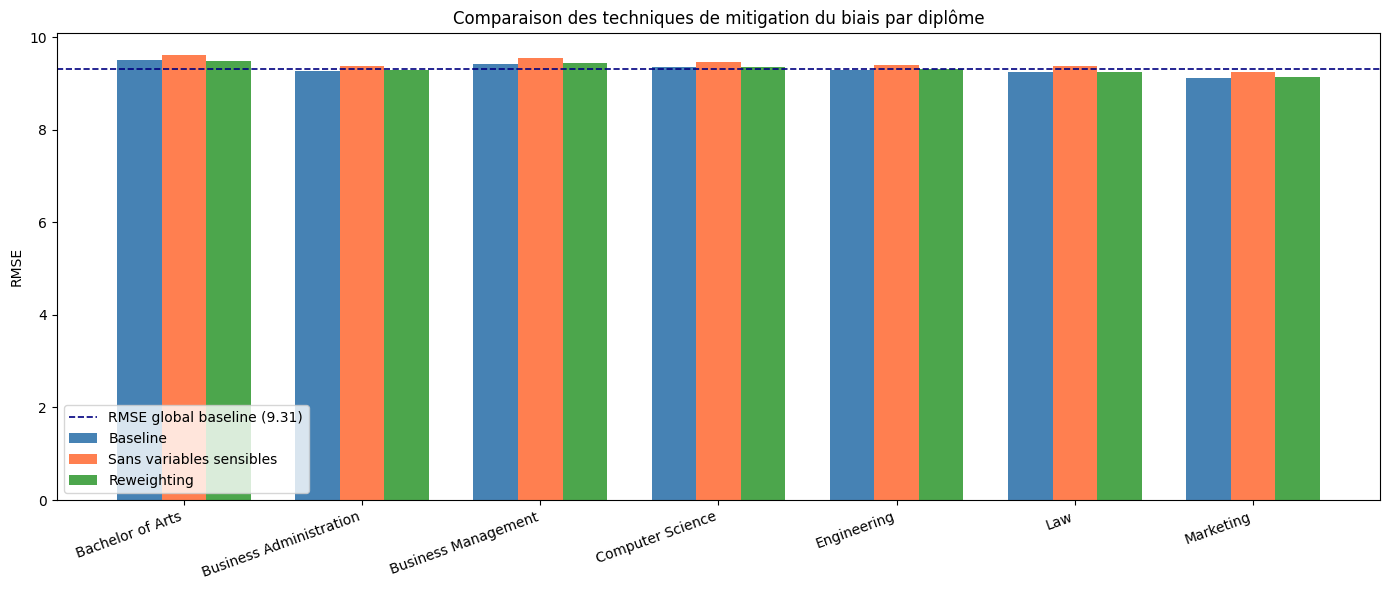


Graphe sauvegardé !


In [15]:
# ── Cellule 7 — Mitigation du biais ──
import gc
from sklearn.utils.class_weight import compute_sample_weight

# Libérer la mémoire avant de commencer
gc.collect()

print("="*55)
print("MITIGATION DU BIAIS")
print("="*55)

# ── Technique 1 : Supprimer les variables sensibles ──
print("\n1. SUPPRESSION DES VARIABLES SENSIBLES")
print("-"*40)

df_work_nosensitive = df_original.drop(
    columns=['taille_etudiant', 'id', 'genre', 'diplôme'],
    errors='ignore'
)

df_encoded_ns = pd.get_dummies(df_work_nosensitive, drop_first=True)
X_ns = df_encoded_ns.drop("score_examen", axis=1)
y_ns = df_encoded_ns["score_examen"]

numeric_cols_ns = X_ns.select_dtypes(include="number").columns
X_ns[numeric_cols_ns] = X_ns[numeric_cols_ns].fillna(X_ns[numeric_cols_ns].median())

scaler_ns = StandardScaler()
X_ns_scaled = scaler_ns.fit_transform(X_ns)

X_temp_ns, X_test_ns, y_temp_ns, y_test_ns, idx_temp_ns, idx_test_ns = \
    train_test_split(X_ns_scaled, y_ns, sensitive_cols.index,
                     test_size=0.20, random_state=42)
X_train_ns, _, y_train_ns, _, _, _ = train_test_split(
    X_temp_ns, y_temp_ns, idx_temp_ns,
    test_size=0.25, random_state=42)

# Libérer X_ns_scaled qui est gros
del X_ns_scaled, X_temp_ns
gc.collect()

xgb_ns = XGBRegressor(n_estimators=100, random_state=42,
                      verbosity=0, n_jobs=1, base_score=0.5)
xgb_ns.fit(X_train_ns, y_train_ns)
preds_ns = xgb_ns.predict(X_test_ns)

# Libérer le modèle après prédiction
del X_train_ns
gc.collect()

sensitive_test_ns = sensitive_cols.loc[idx_test_ns].reset_index(drop=True)
y_test_ns = y_test_ns.reset_index(drop=True)

rmse_ns_global = mean_squared_error(y_test_ns, preds_ns) ** 0.5
print(f"RMSE global (sans variables sensibles) : {rmse_ns_global:.4f}")
print(f"RMSE global (avec variables sensibles) : {rmse_global:.4f}")

genre_rmse_ns = {}
for genre in ['male', 'female']:
    mask = sensitive_test_ns['genre'] == genre
    rmse = mean_squared_error(y_test_ns[mask], preds_ns[mask]) ** 0.5
    genre_rmse_ns[genre] = rmse
    print(f"RMSE {genre:8s} sans sensibles : {rmse:.4f} "
          f"(avant : {genre_rmse[genre]:.4f})")

diplome_rmse_ns = {}
for diplome in sorted(diplomes):
    mask = sensitive_test_ns['diplôme'] == diplome
    if mask.sum() < 10:
        continue
    rmse = mean_squared_error(y_test_ns[mask], preds_ns[mask]) ** 0.5
    diplome_rmse_ns[diplome] = rmse

ecart_avant = max(diplome_rmse.values()) - min(diplome_rmse.values())
ecart_apres = max(diplome_rmse_ns.values()) - min(diplome_rmse_ns.values())
print(f"\nÉcart max diplômes avant : {ecart_avant:.4f}")
print(f"Écart max diplômes après : {ecart_apres:.4f}")

# Libérer xgb_ns avant de créer xgb_rw
del xgb_ns
gc.collect()

# ── Technique 2 : Reweighting par diplôme ──
print("\n2. REWEIGHTING PAR DIPLÔME")
print("-"*40)

X_train2_rw, _, y_train2_rw, _, idx_train2_rw, _ = train_test_split(
    X_temp2, y_temp2, idx_temp,
    test_size=0.25, random_state=42)

sensitive_train = sensitive_cols.loc[idx_train2_rw].reset_index(drop=True)

diplome_counts = sensitive_train['diplôme'].value_counts()
total_rw = len(sensitive_train)
sample_weights = sensitive_train['diplôme'].map(
    lambda d: total_rw / (len(diplome_counts) * diplome_counts[d])
).values

xgb_rw = XGBRegressor(n_estimators=100, random_state=42,
                      verbosity=0, n_jobs=1, base_score=0.5)
xgb_rw.fit(X_train2_rw, y_train2_rw, sample_weight=sample_weights)

del X_train2_rw, y_train2_rw
gc.collect()

preds_rw = xgb_rw.predict(X_test2)
rmse_rw_global = mean_squared_error(y_test2, preds_rw) ** 0.5
print(f"RMSE global (reweighting) : {rmse_rw_global:.4f}")
print(f"RMSE global (baseline)    : {rmse_global:.4f}")

diplome_rmse_rw = {}
for diplome in sorted(diplomes):
    mask = sensitive_test['diplôme'] == diplome
    if mask.sum() < 10:
        continue
    rmse = mean_squared_error(y_test2[mask], preds_rw[mask]) ** 0.5
    diplome_rmse_rw[diplome] = rmse

ecart_rw = max(diplome_rmse_rw.values()) - min(diplome_rmse_rw.values())
print(f"Écart max diplômes reweighting : {ecart_rw:.4f}")

del xgb_rw
gc.collect()

# ── Tableau comparatif ──
print("\n" + "="*65)
print("COMPARAISON DES TECHNIQUES DE MITIGATION")
print("="*65)
print(f"{'Diplôme':30s} {'Baseline':>10} {'Sans sensib.':>12} {'Reweighting':>12}")
print("-"*65)
for diplome in sorted(diplome_rmse.keys()):
    b  = diplome_rmse.get(diplome, float('nan'))
    ns = diplome_rmse_ns.get(diplome, float('nan'))
    rw = diplome_rmse_rw.get(diplome, float('nan'))
    print(f"{diplome:30s} {b:10.4f} {ns:12.4f} {rw:12.4f}")
print("-"*65)
print(f"{'RMSE Global':30s} {rmse_global:10.4f} "
      f"{rmse_ns_global:12.4f} {rmse_rw_global:12.4f}")
print(f"{'Écart max diplômes':30s} {ecart_avant:10.4f} "
      f"{ecart_apres:12.4f} {ecart_rw:12.4f}")

# ── Graphe comparatif ──
x = np.arange(len(diplome_rmse))
width = 0.25
labels_plot = sorted(diplome_rmse.keys())

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, [diplome_rmse[d] for d in labels_plot],
       width, label='Baseline', color='steelblue')
ax.bar(x, [diplome_rmse_ns[d] for d in labels_plot],
       width, label='Sans variables sensibles', color='coral')
ax.bar(x + width, [diplome_rmse_rw[d] for d in labels_plot],
       width, label='Reweighting', color='green', alpha=0.7)
ax.axhline(y=rmse_global, color='navy', linestyle='--',
           linewidth=1.2, label=f'RMSE global baseline ({rmse_global:.2f})')
ax.set_xticks(x)
ax.set_xticklabels(labels_plot, rotation=20, ha='right')
ax.set_ylabel("RMSE")
ax.set_title("Comparaison des techniques de mitigation du biais par diplôme")
ax.legend()
plt.tight_layout()
plt.savefig("bias_mitigation.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGraphe sauvegardé !")

# Part 3. Security 

## Cellule 8 : Attaque adversariale Failure Prediction

SECURITY — ATTAQUE ADVERSARIALE

Étudiant honnête sélectionné — index : 6
Score prédit original : 76.71/100
Objectif : faire descendre le score sous 50

--------------------------------------------------
ATTAQUE 1 : Manipulation de heures_etude uniquement
--------------------------------------------------
Valeur originale heures_etude (scaled) : 0.0805
✅ Score passe sous 50 après réduction de 1.8 unités scaled
   Nouveau score prédit : 49.87/100
   Changement sur 1 seule variable

--------------------------------------------------
ATTAQUE 2 : Manipulation de 2 variables
--------------------------------------------------
✅ Score passe sous 50 avec 2 variables :
   heures_etude  : -1.1 unités scaled
   assiduité     : -1.6 unités scaled
   Nouveau score : 49.51/100
   Changement total : 2.7 unités


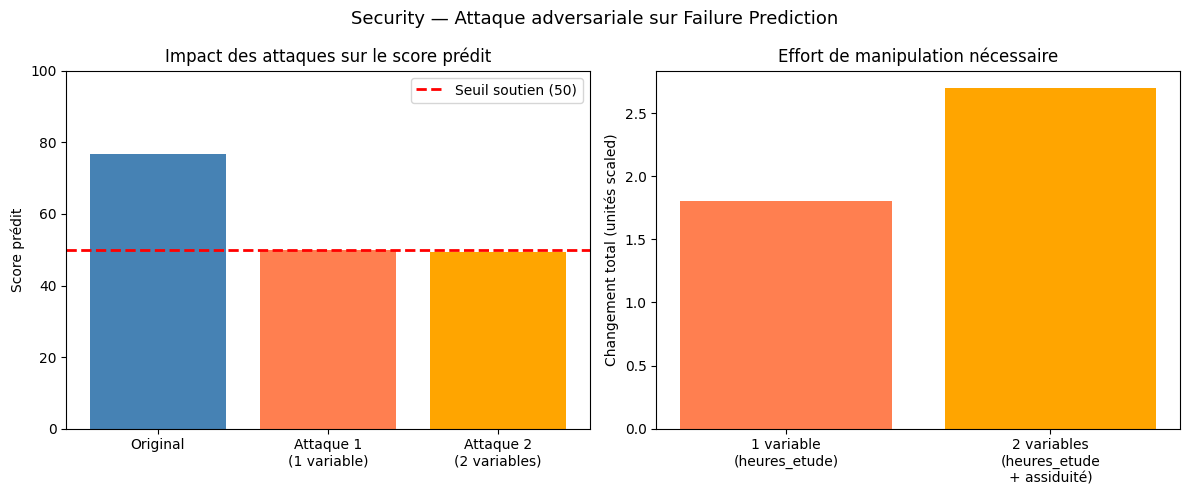


SECURITY — RISQUE POUR L'OCR

Contrairement à la Failure Prediction où un étudiant peut
facilement mentir sur ses heures d'étude déclarées, le risque
pour l'OCR est différent :

1. ÉCRITURE VOLONTAIREMENT ILLISIBLE
   Un étudiant pourrait écrire intentionnellement de façon
   ambiguë pour que l'OCR reconnaisse un mauvais caractère.
   Ex: écrire un '1' qui ressemble à un 'l' ou un 'I'.
   → Risque MODÉRÉ : difficile à contrôler systématiquement.

2. EXPLOITATION DES CONFUSIONS CONNUES
   La matrice de confusion montre des erreurs récurrentes :
   0/O, 1/l/I, S/s, C/c.
   Un étudiant malveillant pourrait exploiter ces confusions
   pour transformer une mauvaise réponse en bonne.
   → Risque RÉEL mais limité par le contexte sémantique.

3. CONCLUSION
   Le risque OCR est moins critique car :
   - Les réponses ont un contexte (mots, phrases)
   - Un humain peut vérifier les cas ambigus
   - L'approche hybride humain-IA recommandée dans le rapport
     principal limite ce risque.



In [ ]:
# ── Cellule 8 — Security : Attaque adversariale Failure Prediction ──

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

print("="*60)
print("SECURITY — ATTAQUE ADVERSARIALE")
print("="*60)

# On prend un étudiant avec score prédit > 50 (ne mérite pas le soutien)
preds_all = xgb.predict(X_test2)
honest_indices = np.where(preds_all > 70)[0]  # étudiant avec bon score
student_idx = honest_indices[0]

original_pred = preds_all[student_idx]
original_features = X_test2[student_idx].copy()

print(f"\nÉtudiant honnête sélectionné — index : {student_idx}")
print(f"Score prédit original : {original_pred:.2f}/100")
print(f"Objectif : faire descendre le score sous 50")

# ── Attaque 1 : Manipuler heures_etude uniquement ──
print("\n" + "-"*50)
print("ATTAQUE 1 : Manipulation de heures_etude uniquement")
print("-"*50)

# Trouver l'index de heures_etude dans X
heures_etude_idx = list(X.columns).index('heures_etude')
original_heures = original_features[heures_etude_idx]

print(f"Valeur originale heures_etude (scaled) : {original_heures:.4f}")

# Diminuer progressivement heures_etude
attack1_found = False
for step in np.arange(0.1, 10, 0.1):
    modified = original_features.copy()
    modified[heures_etude_idx] = original_heures - step
    new_pred = xgb.predict(modified.reshape(1, -1))[0]
    if new_pred < 50:
        print(f"Score passe sous 50 après réduction de {step:.1f} unités scaled")
        print(f"   Nouveau score prédit : {new_pred:.2f}/100")
        print(f"   Changement sur 1 seule variable")
        attack1_step = step
        attack1_pred = new_pred
        attack1_found = True
        break

if not attack1_found:
    print("Impossible de passer sous 50 en manipulant uniquement heures_etude")
    attack1_step = None

# ── Attaque 2 : Manipuler heures_etude + assiduité_classe ──
print("\n" + "-"*50)
print("ATTAQUE 2 : Manipulation de 2 variables")
print("-"*50)

assiduité_idx = list(X.columns).index('assiduité_classe')
original_assiduité = original_features[assiduité_idx]

attack2_found = False
for step_h in np.arange(0.1, 10, 0.5):
    for step_a in np.arange(0.1, 10, 0.5):
        modified = original_features.copy()
        modified[heures_etude_idx] = original_heures - step_h
        modified[assiduité_idx]    = original_assiduité - step_a
        new_pred = xgb.predict(modified.reshape(1, -1))[0]
        if new_pred < 50:
            total_change = step_h + step_a
            print(f"   Score passe sous 50 avec 2 variables :")
            print(f"   heures_etude  : -{step_h:.1f} unités scaled")
            print(f"   assiduité     : -{step_a:.1f} unités scaled")
            print(f"   Nouveau score : {new_pred:.2f}/100")
            print(f"   Changement total : {total_change:.1f} unités")
            attack2_step_h = step_h
            attack2_step_a = step_a
            attack2_pred = new_pred
            attack2_found = True
            break
    if attack2_found:
        break

# ── Visualisation ──
variables_manipulées = ['1 variable\n(heures_etude)', '2 variables\n(heures_etude\n+ assiduité)']
scores_après = [attack1_pred if attack1_found else original_pred,
                attack2_pred if attack2_found else original_pred]
changements  = [attack1_step if attack1_found else 0,
                (attack2_step_h + attack2_step_a) if attack2_found else 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphe 1 — Score avant/après
axes[0].bar(['Original', 'Attaque 1\n(1 variable)', 'Attaque 2\n(2 variables)'],
            [original_pred, 
             attack1_pred if attack1_found else original_pred,
             attack2_pred if attack2_found else original_pred],
            color=['steelblue', 'coral', 'orange'])
axes[0].axhline(y=50, color='red', linestyle='--', linewidth=2,
                label='Seuil soutien (50)')
axes[0].set_ylabel("Score prédit")
axes[0].set_title("Impact des attaques sur le score prédit")
axes[0].legend()
axes[0].set_ylim(0, 100)

# Graphe 2 — Changement minimal nécessaire
axes[1].bar(variables_manipulées, changements, color=['coral', 'orange'])
axes[1].set_ylabel("Changement total (unités scaled)")
axes[1].set_title("Effort de manipulation nécessaire")

plt.suptitle("Security — Attaque adversariale sur Failure Prediction", fontsize=13)
plt.tight_layout()
plt.savefig("security_attack.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Discussion du risque OCR ──
print("\n" + "="*60)
print("SECURITY — RISQUE POUR L'OCR")
print("="*60)
print("""
Contrairement à la Failure Prediction où un étudiant peut
facilement mentir sur ses heures d'étude déclarées, le risque
pour l'OCR est différent :

1. ÉCRITURE VOLONTAIREMENT ILLISIBLE
   Un étudiant pourrait écrire intentionnellement de façon
   ambiguë pour que l'OCR reconnaisse un mauvais caractère.
   Ex: écrire un '1' qui ressemble à un 'l' ou un 'I'.
   → Risque MODÉRÉ : difficile à contrôler systématiquement.

2. EXPLOITATION DES CONFUSIONS CONNUES
   La matrice de confusion montre des erreurs récurrentes :
   0/O, 1/l/I, S/s, C/c.
   Un étudiant malveillant pourrait exploiter ces confusions
   pour transformer une mauvaise réponse en bonne.
   → Risque RÉEL mais limité par le contexte sémantique.

3. CONCLUSION
   Le risque OCR est moins critique car :
   - Les réponses ont un contexte (mots, phrases)
   - Un humain peut vérifier les cas ambigus
   - L'approche hybride humain-IA recommandée dans le rapport
     principal limite ce risque.
""")